# Linear regression in diabetes dataset

Let's explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)).

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [13]:
diabetes
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

Let's explore this variable by looking at the different attributes (keys) of `diabetes`. Note that the `load_diabetes` function does not return dataframes. It returns you a Python dictionary.

In [4]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

#### The next step is to read the description of the dataset. 

Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable. Read the data description carefully to fully understand what each column represents.

*Hint: If your output is ill-formatted by displaying linebreaks as `\n`, it means you are not using the `print` function.*

In [5]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

#### Based on the data description, answer the following questions:

1. How many attributes are there in the data? What do they mean?

1. What is the relation between `diabetes['data']` and `diabetes['target']`?

1. How many records are there in the data?

#### Now explore what are contained in the *data* portion as well as the *target* portion of `diabetes`. 

Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). Inspect the shape of `data` and `target`. Confirm they are consistent with the data description.

In [6]:
# Para confirmar que los datos coinciden con la descripción

print("Forma de los datos (X):", diabetes.data.shape)
print("Forma del objetivo (y):", diabetes.target.shape)

Forma de los datos (X): (442, 10)
Forma del objetivo (y): (442,)


In [14]:
diabetes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


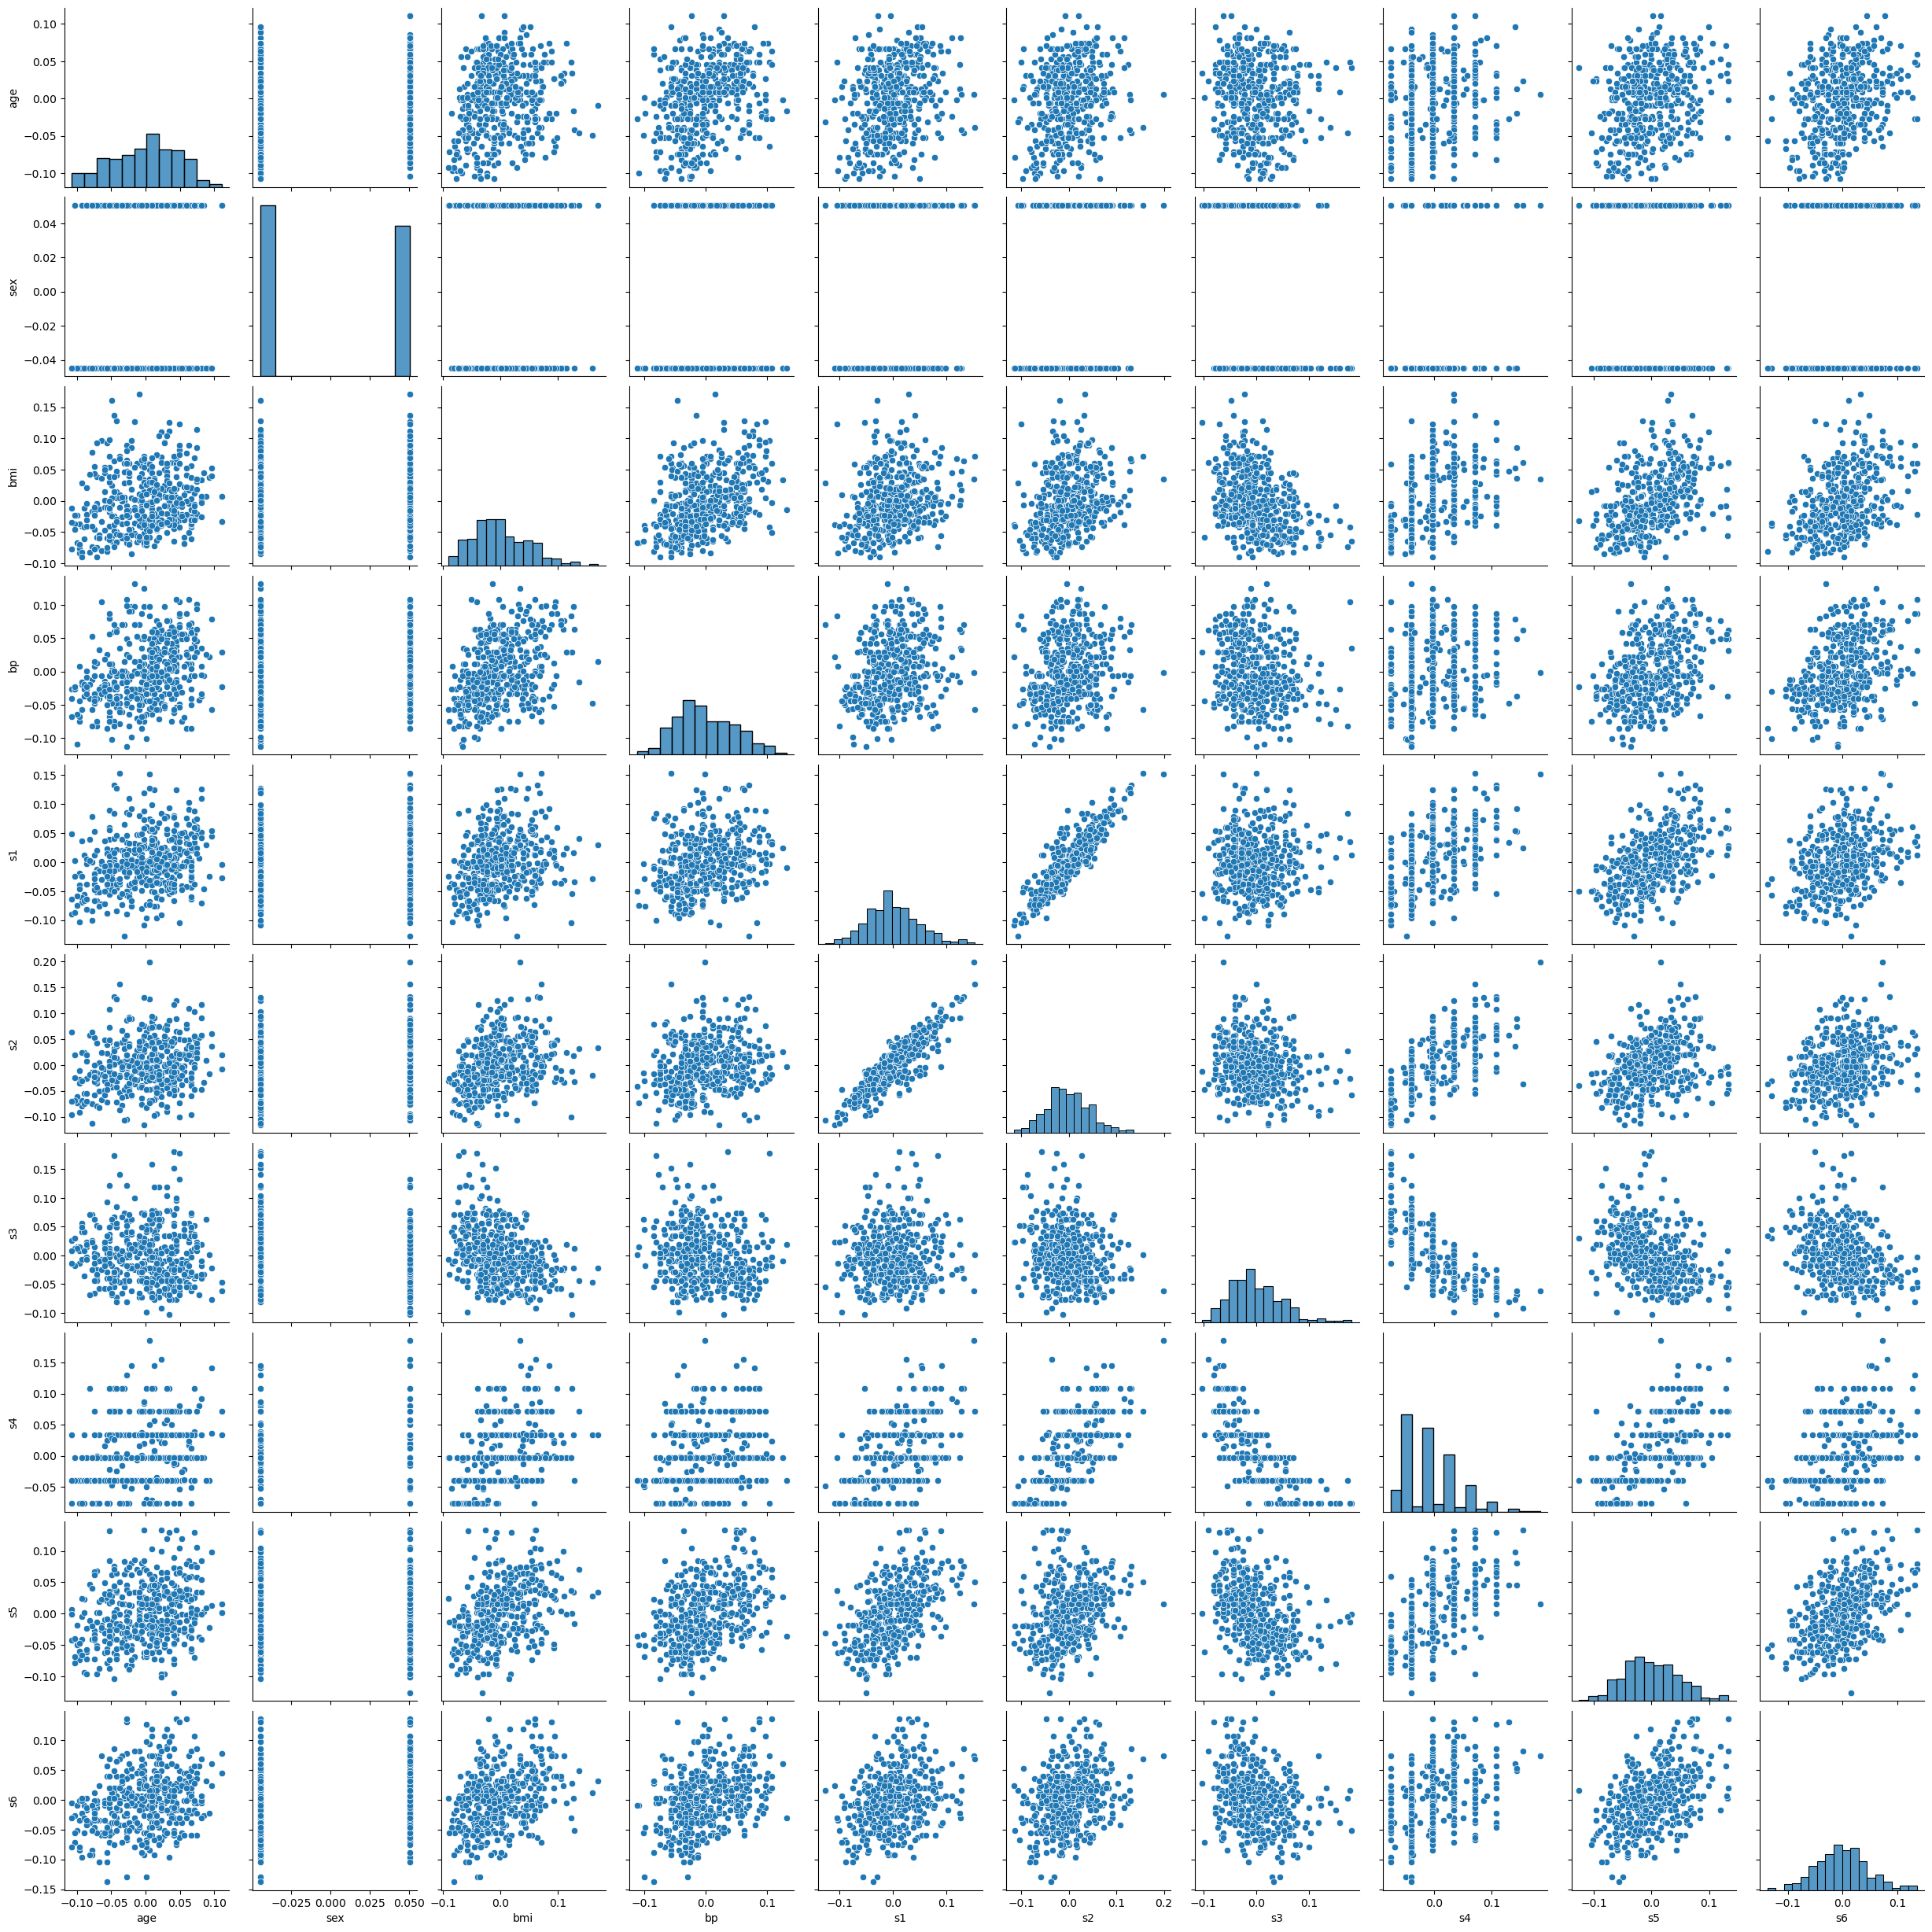

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(diabetes_df)
plt.show()

## Building a regression model

The data have already been split to predictor (*data*) and response (*target*) variables. Given this information, we'll apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset.

#### In the cell below, import the `linear_model` class from `sklearn`. 

In [ ]:
from sklearn import linear_model

#### Create a new instance of the linear regression model and assign the new instance to the variable `diabetes_model`.

In [ ]:
diabetes_model = linear_model.LinearRegression()

#### Next, let's split the training and test data.

Define `diabetes_data_train`, `diabetes_target_train`, `diabetes_data_test`, and `diabetes_target_test`. Use the last 20 records for the test data and the rest for the training data.

In [ ]:
# Datos de entrenamiento (todos menos los últimos 20)
diabetes_data_train = diabetes.data[:-20]
diabetes_target_train = diabetes.target[:-20]

# Datos de test (los últimos 20)
diabetes_data_test = diabetes.data[-20:]
diabetes_target_test = diabetes.target[-20:]

Perform a brief exploratory analysis to investigate the conditions necessary for linear regression. This analysis will help you understand the distribution of the target variable and its correlations with other features.

Fit the training data and target to `diabetes_model`. Print the *intercept* and *coefficients* of the model.

In [ ]:
# Ajustar el modelo
diabetes_model.fit(diabetes_data_train, diabetes_target_train)

# Imprimir parámetros
print("Intercepción (Beta 0):", diabetes_model.intercept_)
print("Coeficientes (Betas):", diabetes_model.coef_)

Intercepción (Beta 0): 152.76429169049118
Coeficientes (Betas): [ 3.06094248e-01 -2.37635570e+02  5.10538048e+02  3.27729878e+02
 -8.14111926e+02  4.92799595e+02  1.02841240e+02  1.84603496e+02
  7.43509388e+02  7.60966464e+01]


#### Inspecting the results

From the outputs you should have seen:

- The intercept is a float number.
- The coefficients are an array containing 10 float numbers.

This is the linear regression model fitted to your training dataset.

#### Using your fitted linear regression model, predict the *y* of `diabetes_data_test`.

In [ ]:
diabetes_target_pred = diabetes_model.predict(diabetes_data_test)

#### Print your `diabetes_target_test` and compare with the prediction. 

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("Predicciones:", diabetes_target_pred)
print("Valores reales:", diabetes_target_test)

Predicciones: [197.61898486 155.44031962 172.88875144 111.53270645 164.79397301
 131.06765869 259.12441219 100.47873746 117.06005372 124.30261597
 218.36868146  61.19581944 132.24837933 120.33293546  52.54513009
 194.03746764 102.5756431  123.56778709 211.03465323  52.60221696]
Valores reales: [233.  91. 111. 152. 120.  67. 310.  94. 183.  66. 173.  72.  49.  64.
  48. 178. 104. 132. 220.  57.]


#### Is `diabetes_target_test` exactly the same as the model prediction? Use different error metrics

In [ ]:
# Métricas
print("Mean Squared Error (MSE):", mean_squared_error(diabetes_target_test, diabetes_target_pred))
print("Coeficiente de determinación (R2):", r2_score(diabetes_target_test, diabetes_target_pred))

Mean Squared Error (MSE): 2004.518686334209
Coeficiente de determinación (R2): 0.5850854274471952


#### Iterate with a new model to assess if any improvements can be made compared to the previous one. Consider reducing the number of variables or using `StandardScaler` to enhance model performance.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Selección de variables: Vamos a usar solo 'bmi', 's5' (log de triglicéridos) y 's6' (glucosa)
# Estas variables suelen tener mayor correlación con el target.
feature_indices = [2, 8, 9] 
X_train_reduced = diabetes_data_train[:, feature_indices]
X_test_reduced = diabetes_data_test[:, feature_indices]

# 2. Escalado (StandardScaler)
# Aunque el dataset original está pre-procesado, aplicamos el scaler para seguir las mejores prácticas.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

# 3. Entrenar el nuevo modelo
new_diabetes_model = LinearRegression()
new_diabetes_model.fit(X_train_scaled, diabetes_target_train)

# 4. Predicción y evaluación
new_target_pred = new_diabetes_model.predict(X_test_scaled)

print("--- Evaluación del Nuevo Modelo (Variables Reducidas) ---")
print("Nuevo MSE:", mean_squared_error(diabetes_target_test, new_target_pred))
print("Nuevo R2 Score:", r2_score(diabetes_target_test, new_target_pred))

# Comparativa rápida
print(f"\nInterpretación: Si el R2 es mayor que el anterior, el modelo es más robusto.")

--- Evaluación del Nuevo Modelo (Variables Reducidas) ---
Nuevo MSE: 2128.4119609796867
Nuevo R2 Score: 0.5594408049040631

Interpretación: Si el R2 es mayor que el anterior, el modelo es más robusto.


En conclusión, el modelo de regresión lineal inicial alcanzó un coeficiente de determinación ($R^2$) de 0.585, lo que indica una capacidad predictiva moderada sobre la progresión de la diabetes. Al intentar optimizar el modelo mediante la selección de variables clave (IMC y niveles de suero) y el uso de StandardScaler, el rendimiento descendió ligeramente a un 0.559. Este resultado demuestra que, en este conjunto de datos específico, las variables eliminadas aportaban información relevante que el modelo simplificado no pudo capturar. Además, dado que los datos originales ya se encontraban pre-procesados y escalados, la aplicación de transformaciones adicionales no generó una mejora significativa, subrayando la importancia de evaluar cada paso del pre-procesamiento según las características nativas del dataset.